In [1]:
import os

import h5py
import numpy as np
import pandas as pd

from mlpng.generator import Generator
from mlpng.utils import plot_predictions

2026-03-24 13:20:16.148398: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-24 13:20:16.177455: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 13:20:16.177480: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 13:20:16.178302: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-24 13:20:16.183129: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-24 13:20:16.184001: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
NSIMS = 100
# FNL_MIN, FNL_MAX = -1000.0, 1000.0

NSIDE_CONFIGS = {
    64:  ("settings/n64.json",  "data/data/l191_n64_T_10000_p1.0.hdf5"),
    # 128: ("settings/n128.json", "data/data/l383_n128_T_10000_p1.0.hdf5"),
    # 256: ("settings/n256.json", "data/data/l767_n256_T_10000_p1.0.hdf5"),
}

SHAPE_SETS = {
    "local": ["local"],
    # "all":   ["local", "equilateral", "orthogonal"],
}

LENSING_OPTIONS = [False, True]

In [3]:
generators = {}
for nside, (settings_file, _) in NSIDE_CONFIGS.items():
    generators[nside] = Generator(
        argv=[settings_file, "--nsims", "10000", "--lensing", "--shapes", "all"]
    )

In [4]:
def sigma_stats(residuals, sigma):
    empirical_sigma = np.std(residuals)
    print(f"  Fisher σ: {sigma:.4f},  Empirical σ: {empirical_sigma:.4f}  (ratio: {empirical_sigma / sigma:.3f})")
    expected = {1: 68.27, 2: 95.45, 3: 99.73}
    for n, exp in expected.items():
        within = np.sum(np.abs(residuals) < n * sigma)
        print(f"  {n}σ: {100 * within / len(residuals):.1f}% (expected {exp:.1f}%)")


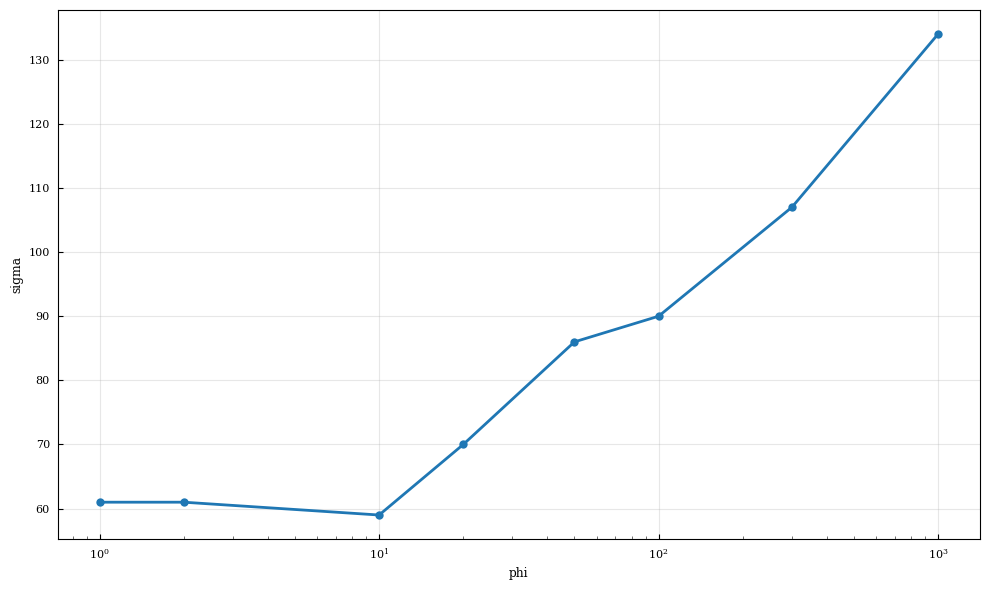

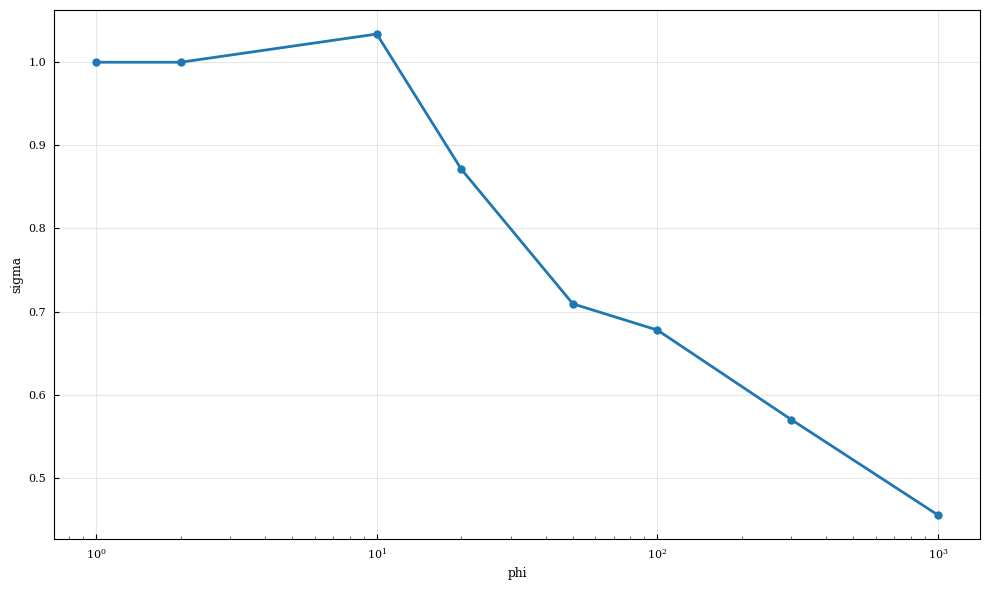

In [5]:
import matplotlib.pyplot as plt

phi = np.array([1, 2, 10, 20, 50, 100, 300, 1000])
sigma = np.array([61, 61, 59, 70, 86, 90, 107, 134])

plt.figure(figsize=(10, 6))
plt.plot(phi, sigma, marker='o', linewidth=2, markersize=6)
plt.xlabel('phi')
plt.ylabel('sigma')
plt.xscale('log')  # log scale for x-axis (optional)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(phi, sigma[0] / sigma, marker='o', linewidth=2, markersize=6)
plt.xlabel('phi')
plt.ylabel('sigma')
plt.xscale('log')  # log scale for x-axis (optional)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# rng = np.random.default_rng(42)
# results = []

# for nside, (_, data_file) in NSIDE_CONFIGS.items():
#     gen = generators[nside]
#     pol_idxs = gen.pol_idxs()
#     fnl_true = rng.uniform(-1000.0, 1000.0, (NSIMS, 1, 1))

#     for lensed in LENSING_OPTIONS:
#         l_str = "lensed" if lensed else "unlensed"

#         for set_name, shapes in SHAPE_SETS.items():
#             for shape in shapes:
#                 label = f"{l_str} {shape}"
#                 print(f"\n=== {label} ===")

#                 with h5py.File(data_file, "r") as f:
#                     alm_l  = f[f"alm_l/{l_str}/{shape}"][:][:NSIMS]
#                     alm_nl = f[f"alm_nl/{l_str}/{shape}"][:][:NSIMS]

#                 if not lensed:
#                     alm_l = alm_l[:, pol_idxs]

#                 alm = alm_l + fnl_true * alm_nl

#                 ksw = gen.get_ksw(shape, lensed=lensed)
#                 fisher = ksw.compute_fisher()
#                 sigma = 1.0 / np.sqrt(fisher)
#                 print(f"  Fisher: {fisher:.6f},  \u03c3: {sigma:.4f}")

#                 estimates, *_ = ksw.compute_estimate_batch(
#                     lambda idx, _alm=alm, _lensed=lensed: gen.icov_func(_alm[idx], lensed=_lensed),
#                     # range(NSIMS),
#                     range(100),
#                     fisher=fisher,
#                 )
#                 estimates = estimates.T.flatten()
#                 fnl_flat  = fnl_true.flatten()
#                 residuals = estimates - fnl_flat

#                 sigma_stats(residuals, sigma)

#                 plot_predictions(
#                     fnl_flat, estimates,
#                     sigma=sigma,
#                     title=f"KSW predictions for {label} (σ={np.std(residuals):.4f})",
#                     save=False, show=True, close=True, legend=False,
#                 )

#                 results.append({
#                     "nside":        nside,
#                     "shape":        shape,
#                     "lensed":       l_str,
#                     "set":          set_name,
#                     "sigma":        round(float(sigma), 4),
#                     "mean_resid":   round(float(np.mean(residuals)), 4),
#                     "std_resid":    round(float(np.std(residuals)), 4),
#                 })

# display(pd.DataFrame(results))

In [7]:
# rng = np.random.default_rng(42)
# results = []

# for nside, (_, data_file) in NSIDE_CONFIGS.items():
#     gen = generators[nside]
#     pol_idxs = gen.pol_idxs()
#     fnl_true = rng.uniform(-100.0, 100.0, (NSIMS, 1, 1))

#     for lensed in LENSING_OPTIONS:
#         l_str = "lensed" if lensed else "unlensed"

#         for set_name, shapes in SHAPE_SETS.items():
#             for shape in shapes:
#                 label = f"{l_str} {shape}"
#                 print(f"\n=== {label} ===")

#                 with h5py.File(data_file, "r") as f:
#                     alm_l  = f[f"alm_l/{l_str}/{shape}"][:][:NSIMS]
#                     alm_nl = f[f"alm_nl/{l_str}/{shape}"][:][:NSIMS]

#                 if not lensed:
#                     alm_l = alm_l[:, pol_idxs]

#                 alm = alm_l + fnl_true * alm_nl

#                 ksw = gen.get_ksw(shape, lensed=lensed)
#                 fisher = ksw.compute_fisher()
#                 sigma = 1.0 / np.sqrt(fisher)
#                 print(f"  Fisher: {fisher:.6f},  \u03c3: {sigma:.4f}")

#                 estimates, *_ = ksw.compute_estimate_batch(
#                     lambda idx, _alm=alm, _lensed=lensed: gen.icov_func(_alm[idx], lensed=_lensed),
#                     range(NSIMS),
#                     fisher=fisher,
#                 )
#                 estimates = estimates.T.flatten()
#                 fnl_flat  = fnl_true.flatten()
#                 residuals = estimates - fnl_flat

#                 sigma_stats(residuals, sigma)

#                 plot_predictions(
#                     fnl_flat, estimates,
#                     sigma=sigma,
#                     title=f"KSW predictions for {label} (σ={np.std(residuals):.4f})",
#                     save=False, show=True, close=True,
#                 )

#                 results.append({
#                     "nside":        nside,
#                     "shape":        shape,
#                     "lensed":       l_str,
#                     "set":          set_name,
#                     "sigma":        round(float(sigma), 4),
#                     "mean_resid":   round(float(np.mean(residuals)), 4),
#                     "std_resid":    round(float(np.std(residuals)), 4),
#                 })

# display(pd.DataFrame(results))


=== lensed local (φ=1) ===


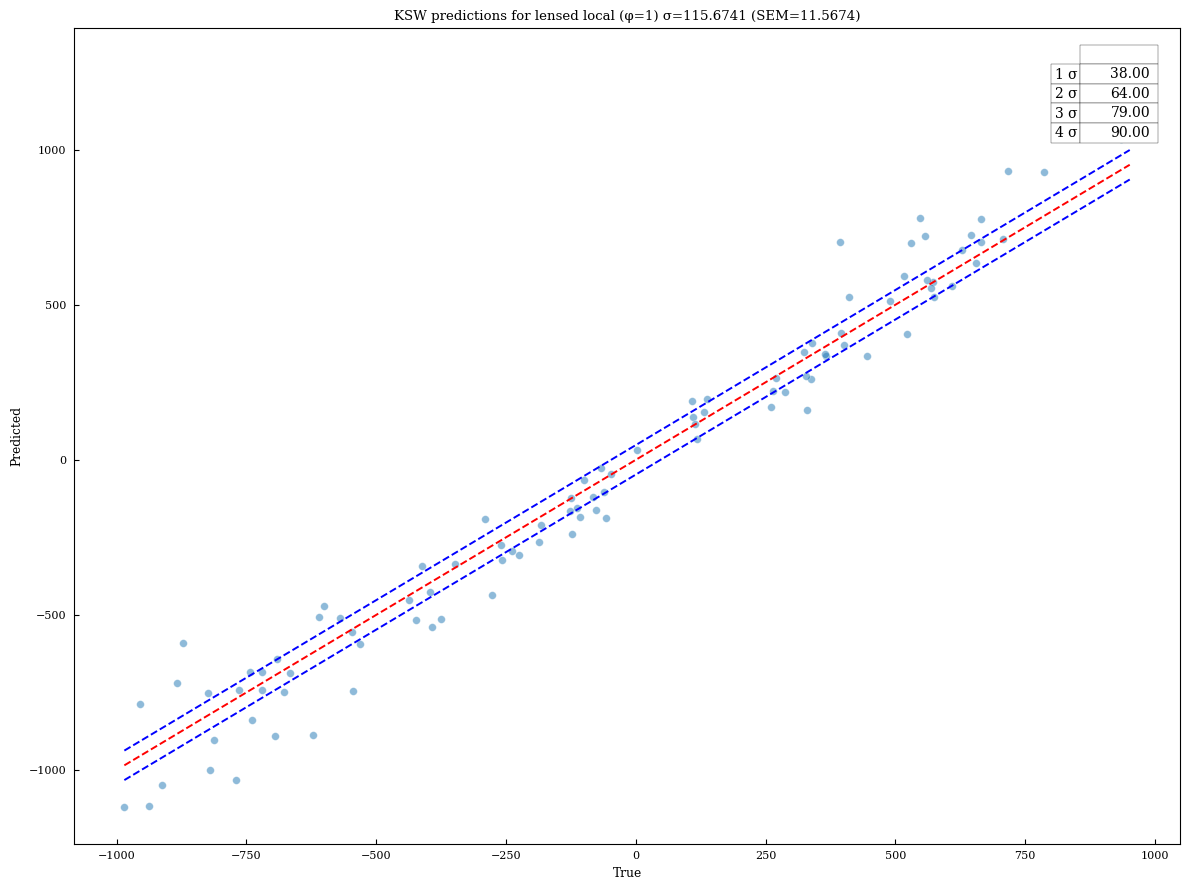


=== lensed local (φ=2) ===


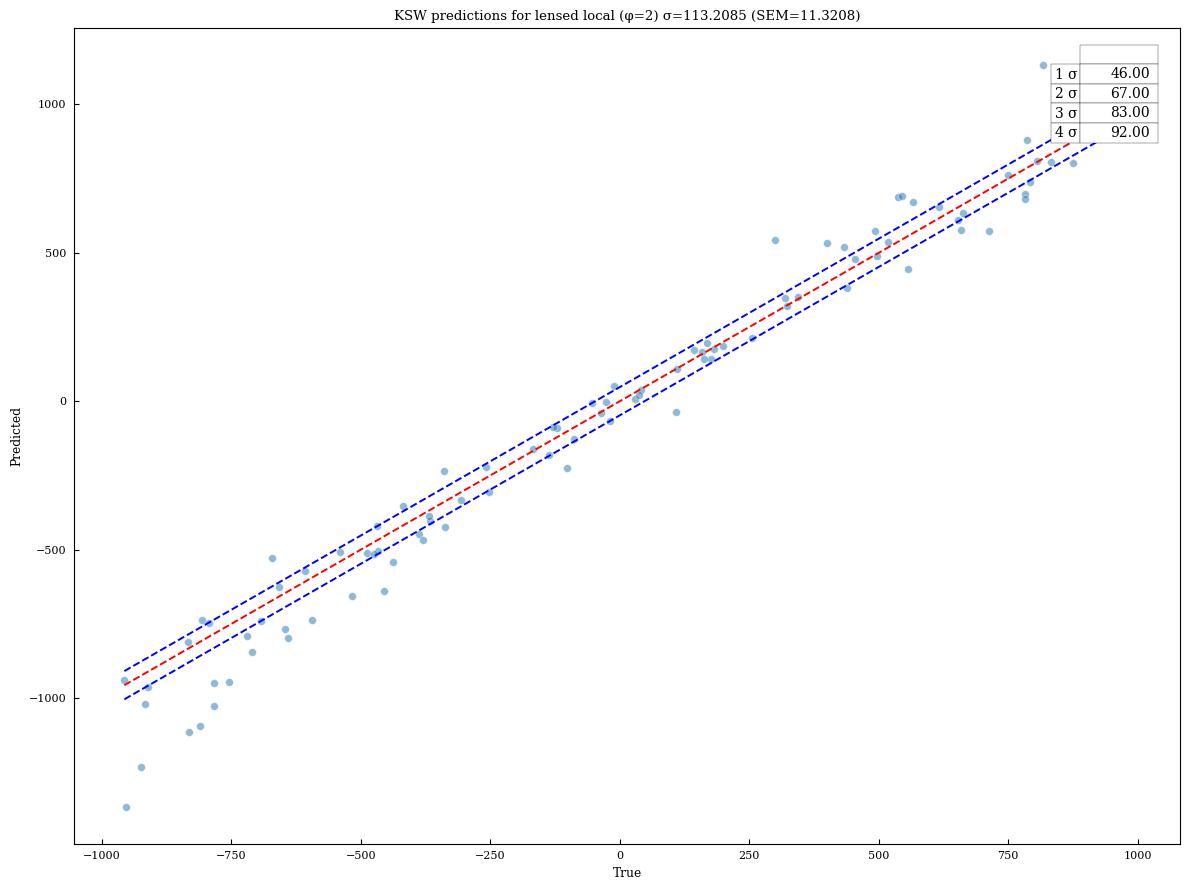


=== lensed local (φ=10) ===


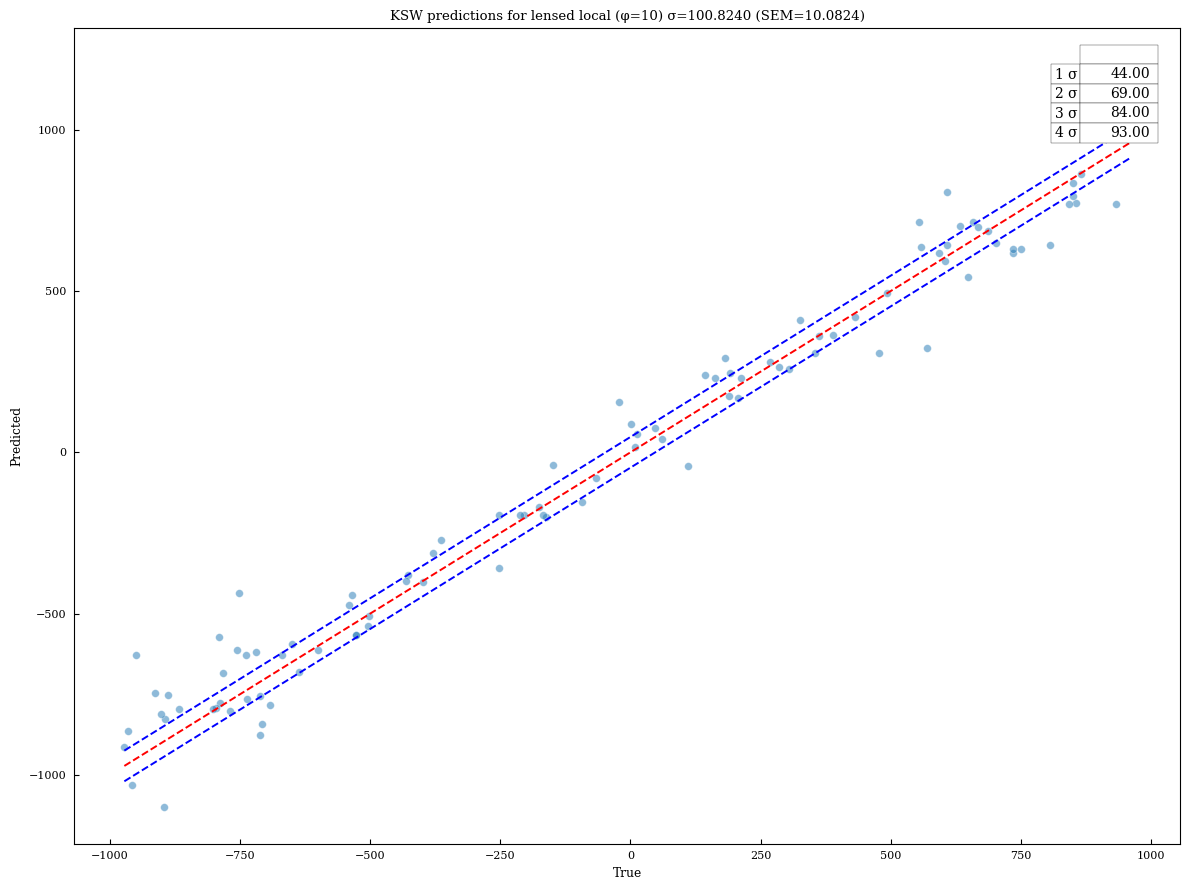


=== lensed local (φ=20) ===


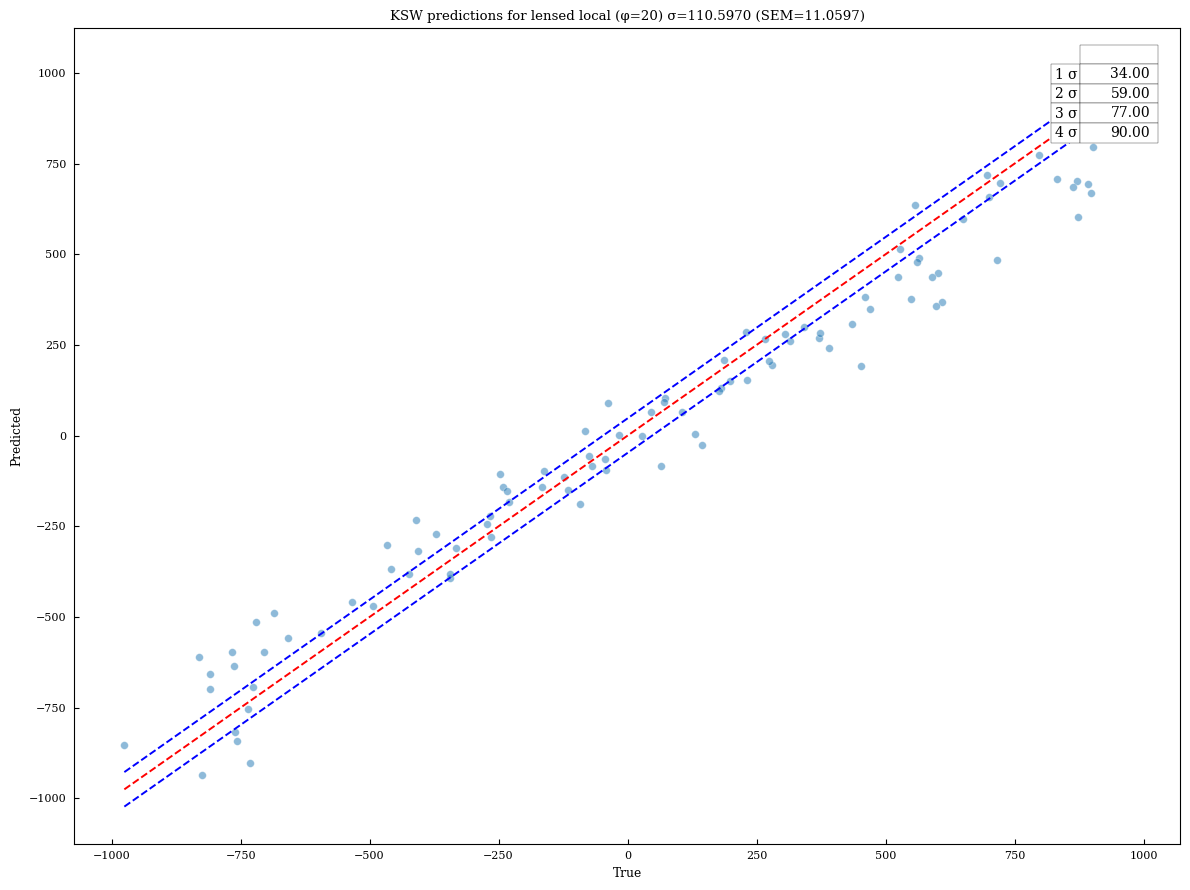


=== lensed local (φ=50) ===


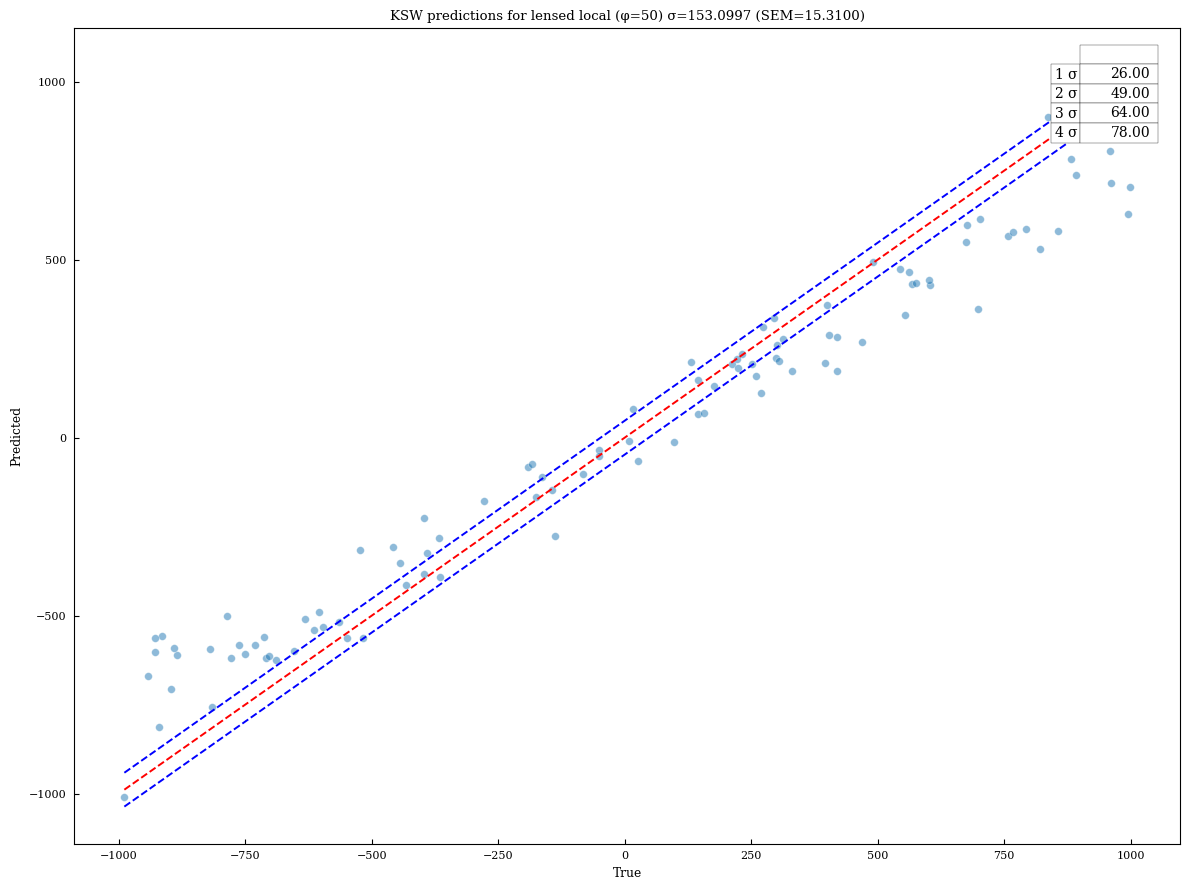


=== lensed local (φ=100) ===


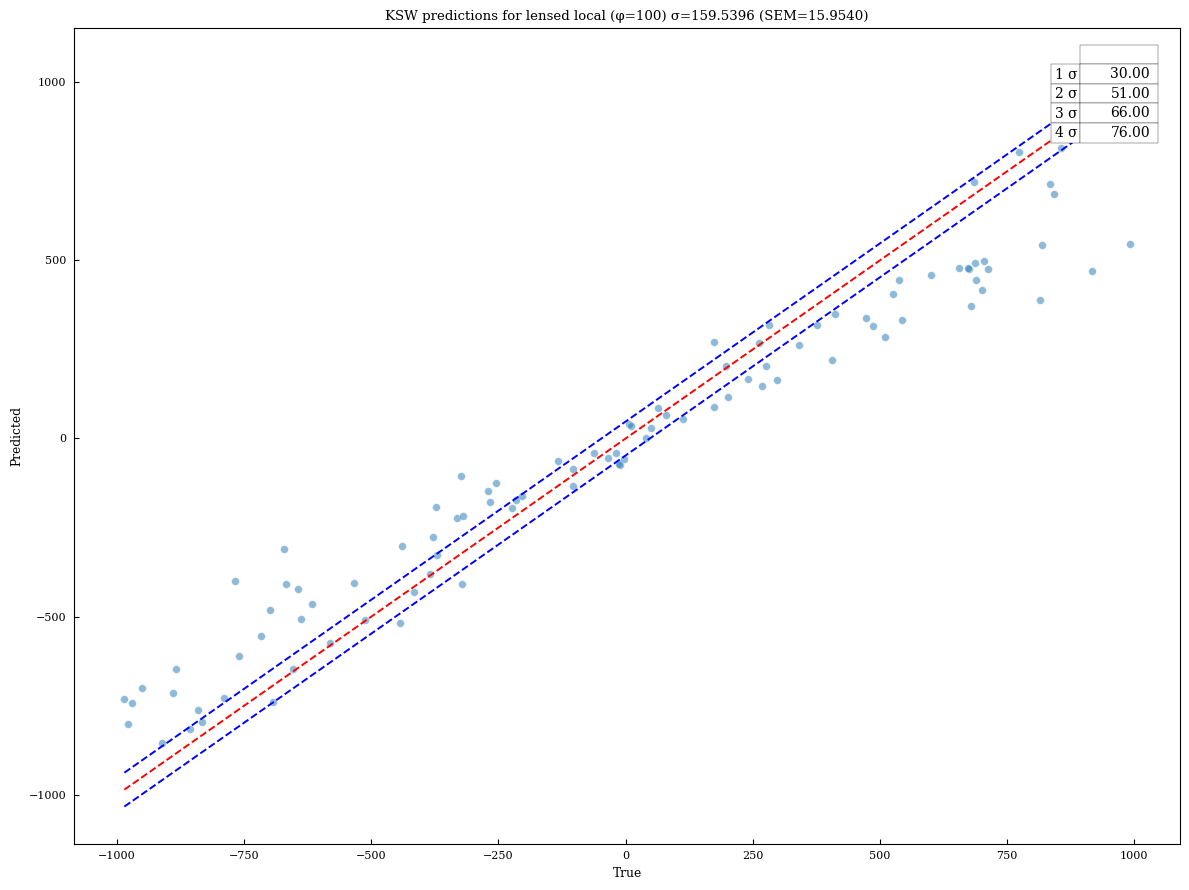


=== lensed local (φ=300) ===


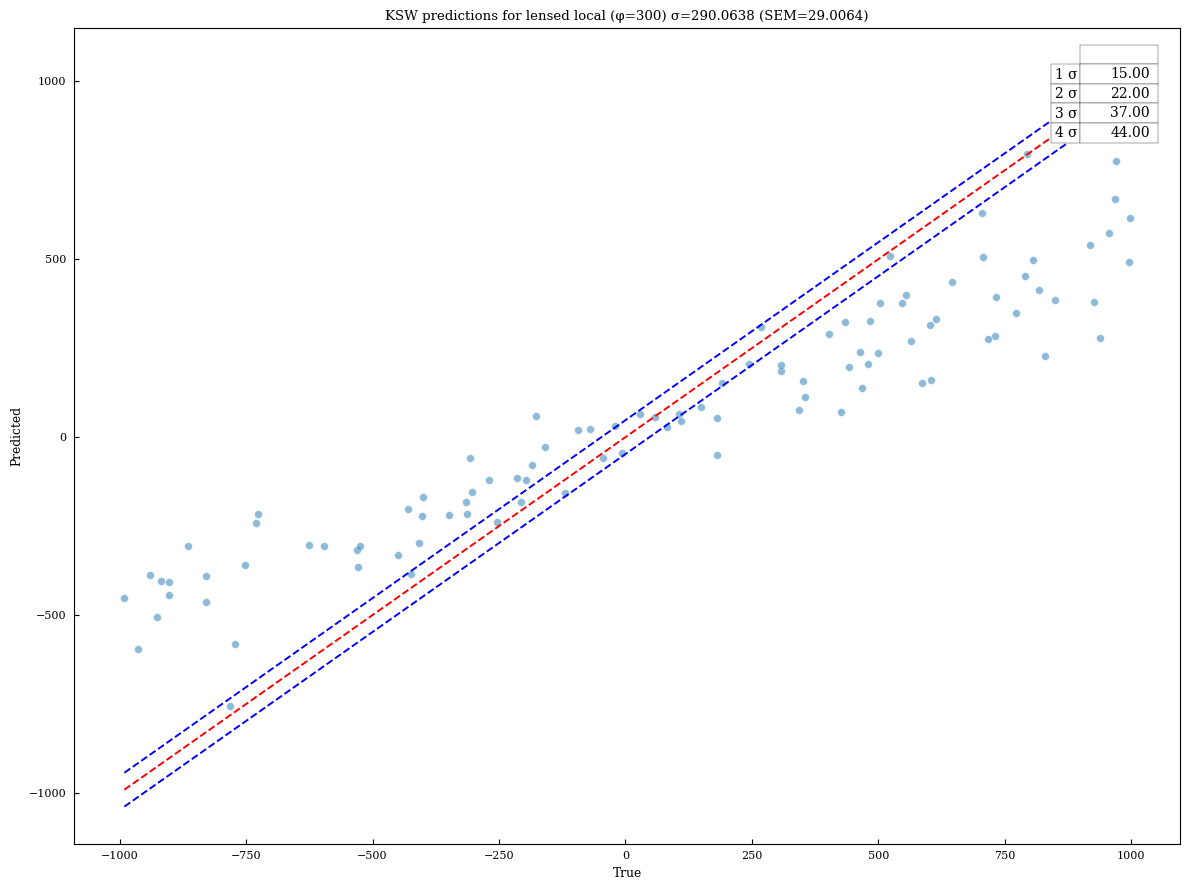


=== lensed local (φ=1000) ===


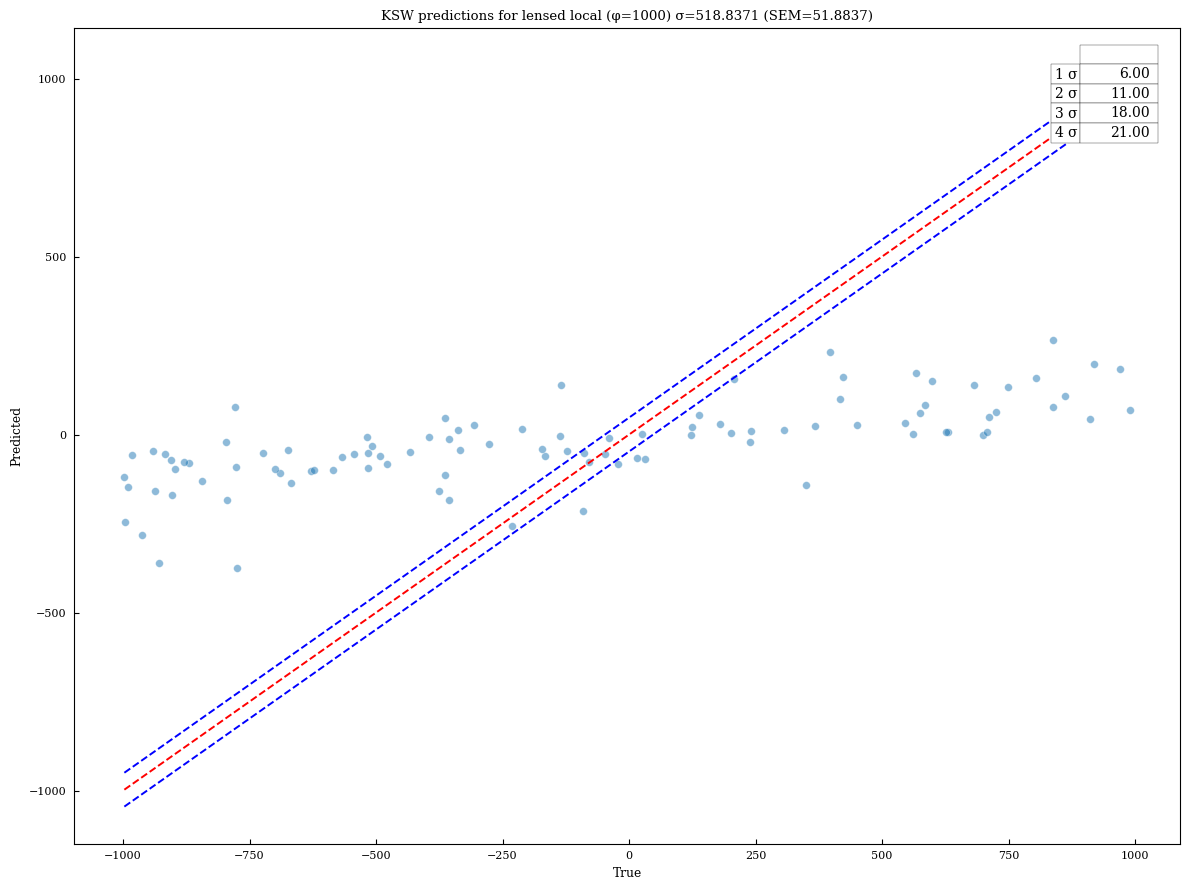

,phi,nside,shape,lensed,set,sigma,mean_resid,std_resid,sem_resid
0,1,64,local,lensed,local,47.5849,0.0854,115.6741,11.5674
1,2,64,local,lensed,local,47.5849,-16.9231,113.2085,11.3208
2,10,64,local,lensed,local,47.5849,15.4122,100.8240,10.0824
3,20,64,local,lensed,local,47.5849,-22.3576,110.5970,11.0597
4,50,64,local,lensed,local,47.5849,-5.8352,153.0997,15.3100
5,100,64,local,lensed,local,47.5849,-11.3139,159.5396,15.9540
6,300,64,local,lensed,local,47.5849,-31.8746,290.0638,29.0064
7,1000,64,local,lensed,local,47.5849,98.4780,518.8371,51.8837


In [8]:
import io
from contextlib import redirect_stdout
import lenspyx
import numpy as np
import healpy as hp

phis = [1, 2, 10, 20, 50, 100, 300, 1000]

rng = np.random.default_rng(42)
results = []

for phi in phis:
    for nside, (_, data_file) in NSIDE_CONFIGS.items():
        gen = generators[nside]
        pol_idxs = gen.pol_idxs()
        fnl_true = rng.uniform(-1000.0, 1000.0, (NSIMS, 1, 1))

        lmax_len = len(gen.ells)
        fl = np.arange(lmax_len + 1) * np.arange(1, lmax_len + 2)
        fl = np.sqrt(fl)
        geom_info = ("healpix", {"nside": gen.nside})

        for lensed in [True]:
            l_str = "lensed" if lensed else "unlensed"

            for set_name, shapes in SHAPE_SETS.items():
                for shape in shapes:
                    label = f"{l_str} {shape} (φ={phi})"
                    print(f"\n=== {label} ===")

                    with h5py.File(data_file, "r") as f:
                        alm_l  = f[f"alm_l/unlensed/{shape}"][:][:NSIMS]
                        alm_nl = f[f"alm_nl/unlensed/{shape}"][:][:NSIMS]
                        alm_phi_all = f["alm_phi"][:][:NSIMS]

                    # Process lensing for each simulation
                    alm_lensed_list = []
                    with redirect_stdout(io.StringIO()):
                        for sim_idx in range(NSIMS):
                            fnl_vals = fnl_true[sim_idx].flatten()

                            alm = alm_l[sim_idx].astype(np.complex128) + np.einsum(
                                "i...,i...->...", fnl_vals, alm_nl[sim_idx]
                            )
                            alm = np.asarray(alm, dtype=np.complex128)
                            alm_phi = alm_phi_all[sim_idx] * phi

                            # Apply deflection field
                            dlm = hp.almxfl(alm_phi, fl)

                            # Lens the alm
                            lenmap = lenspyx.alm2lenmap(
                                alm,
                                dlm,
                                geometry=geom_info,
                                nthreads=1,
                            )

                            # Convert lensed map back to alm
                            lensed_alm = hp.map2alm(lenmap, lmax=gen.lmax, use_pixel_weights=True)
                            alm_lensed_list.append(lensed_alm)

                    # Stack lensed alms: shape should be (NSIMS, npol, nalm)
                    alm_combined = np.array(alm_lensed_list, dtype=np.complex128)

                    ksw = gen.get_ksw(shape, lensed=lensed)
                    fisher = ksw.compute_fisher()
                    sigma = 1.0 / np.sqrt(fisher)

                    estimates, *_ = ksw.compute_estimate_batch(
                        lambda idx, _alm=alm_combined, _lensed=lensed: gen.icov_func(_alm[idx, [0]], lensed=_lensed),
                        range(NSIMS),
                        fisher=fisher,
                    )
                    estimates = estimates.T.flatten()
                    fnl_flat  = fnl_true.flatten()
                    residuals = estimates - fnl_flat
                    sem_resid = np.std(residuals) / np.sqrt(len(residuals))
                    plot_predictions(
                        fnl_flat, estimates,
                        sigma=sigma,
                        title=f"KSW predictions for {label} σ={np.std(residuals):.4f} (SEM={sem_resid:.4f})",
                        save=False, show=True, close=True, legend=False,
                    )

                    results.append({
                        "phi":          phi,
                        "nside":        nside,
                        "shape":        shape,
                        "lensed":       l_str,
                        "set":          set_name,
                        "sigma":        round(float(sigma), 4),
                        "mean_resid":   round(float(np.mean(residuals)), 4),
                        "std_resid":    round(float(np.std(residuals)), 4),
                        "sem_resid":    round(float(sem_resid), 4),
                    })

display(pd.DataFrame(results))
